# Descarga y procesamiento de datos

Este notebook se encarga de descargar los datos necesarios para el proyecto y realizar un procesamiento inicial de los mismos. El preambulo a continuación prepara el entorno de trabajo.

In [6]:
# Librerías necesarias.
import yfinance
import os
import pandas
import ta
import matplotlib.pyplot

# Constantes.
ROOT_DIR = os.path.abspath("..")


Nuestros en bruto consisten en los valores de cierre de ciertas accioenes a final del día por un periodo de 15 años. Para esto, utilizaremos la librería `yfinance` que nos permite descargar datos históricos de acciones de manera sencilla.

In [7]:
# Listado de acciones que descargar.
TICKERS = [ 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'BBVA' ]

# Creación del directorio de datos si no existe.
DATA_DIR = f"{ROOT_DIR}/data"
os.makedirs(DATA_DIR, exist_ok=True)

# Descarga de datos.
TICKER_RAW_DATA = {}
for ticker in TICKERS:
    # Si ya existen los datos, no los volvemos a descargar.
    if os.path.exists(f"{DATA_DIR}/{ticker}/raw.csv"):
        # Cargar datos desde el CSV.
        data = pandas.read_csv(f"{DATA_DIR}/{ticker}/raw.csv", index_col=0, parse_dates=True)
        TICKER_RAW_DATA[ticker] = data
        continue
    # Descargar datos de la acción.
    data = yfinance.download(ticker, period="15y", progress=False)
    # Fix multiindex de conlumnas.
    data.columns = data.columns.droplevel(1)
    # Guardar datos en formato CSV.
    os.makedirs(f"{DATA_DIR}/{ticker}", exist_ok=True)
    data.to_csv(f"{DATA_DIR}/{ticker}/raw.csv")
    # Almacenar los datos descargados.
    TICKER_RAW_DATA[ticker] = data

Una vez tenemos los datos en crudo, eliminaremos filas con valores faltantes para poder trabajar con un dataset limpio.

In [8]:
# Eliminar filas con valores faltantes.
for ticker, data in TICKER_RAW_DATA.items():
    # Eliminar filas con valores faltantes.
    data.dropna(inplace=True)

Ahora tenemos que generar una grán batería de indicadores técnicos a partir de estos datos en crudo. Para esto, utilizaremos la librería `ta` que nos permite calcular una gran variedad de indicadores técnicos de manera sencilla. Tenemos ademas que hacer algunos cálculos manuales para poder corrregir indicadores que aparecen con valores faltantes. Nos quedaremos con los ultimos 10 años de datos para evitar usar las medias móviles del comienzo del dataset, que aparecen con valores faltantes.

Además, nuestro target de predicción será el retorno porcentual del día siguiente, calculado como `(Close_{t+1} - Close_t) / Close_t`. Esto nos permitirá formular nuestro problema como una tarea de regresión, donde queremos predecir el retorno futuro de las acciones. Para evitar trabajar con valores muy pequeños, multiplicaremos este retorno por 100 para expresarlo en porcentaje.

In [14]:
TICKER_DATA = {}
for ticker, data in TICKER_RAW_DATA.items():
    # Asegurar que se ordene por fecha ascendente.
    data.sort_index(inplace=True)
    # Generar todos los indicadores técnicos.
    ta.add_all_ta_features(data, open="Open", high="High", low="Low", close="Close", volume="Volume")
    # Fusionar las columnas de tendencia PSAR para obtener una métrica correcta.
    data["psar_tmp"] = data["trend_psar_up"].fillna(data["trend_psar_down"])
    data["psar"] = data["Close"] - data["psar_tmp"]
    data.drop(columns=["trend_psar_up", "trend_psar_down", "psar_tmp"], inplace=True)
    # Calcular el target como el retorno porcentual del día siguiente.
    data["target"] = (data["Close"].shift(-1) - data["Close"]) / data["Close"] * 100
    # Filtar sólo los últimos 10 años de datos.
    data = data[data.index >= (data.index[-1] - pandas.DateOffset(years=10))]
    # Guardar datos procesados en formato CSV.
    data.to_csv(f"{DATA_DIR}/{ticker}/processed.csv")
    TICKER_DATA[ticker] = data
    

A modo de referencia, véase a continuación la gráfica con los precios de cierre de las acciones a lo largo del tiempo, para cada una de las acciones que estamos analizando.

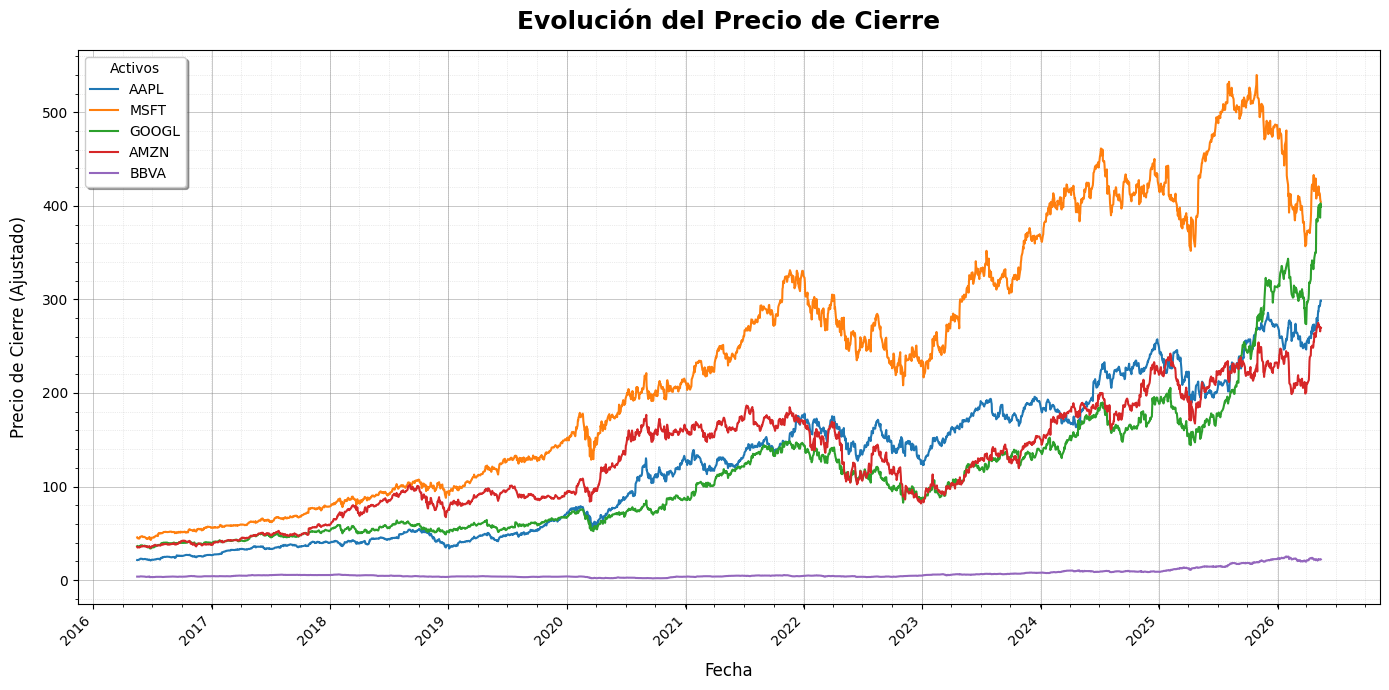

In [15]:
matplotlib.pyplot.style.use('default')

fig, ax = matplotlib.pyplot.subplots(figsize=(14, 7), dpi=100)

for ticker, data in TICKER_DATA.items():
    data["Close"].plot(ax=ax, label=ticker, linewidth=1.5)

ax.set_title("Evolución del Precio de Cierre", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Fecha", fontsize=12, labelpad=10)
ax.set_ylabel("Precio de Cierre (Ajustado)", fontsize=12, labelpad=10)

ax.legend(title="Activos", loc="upper left", frameon=True, shadow=True, fontsize=10)

matplotlib.pyplot.xticks(rotation=45, fontsize=10)
matplotlib.pyplot.yticks(fontsize=10)

ax.minorticks_on()
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5, alpha=0.6)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)# Add subgrid for better readability

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

Una vez tenemos estos datos, procedemos a particionarlos en conjuntos de entrenamiento, validación y test, para poder entrenar nuestros modelos posteriormente. Seguiremos una partición temporal, es decir, usaremos los datos más antiguos para el entrenamiento y los más recientes para la validación y el test. Esto es importante para evitar el data leakage y asegurarnos de que nuestros modelos generalizan bien a datos futuros. La proporción de datos que usaremos para cada conjunto será del 70% para entrenamiento, 15% para validación y 15% para test.

In [16]:
# Particionar datos en entrenamiento, validación y test.
TICKER_SPLIT_DATA = {}
for ticker, data in TICKER_DATA.items():
    # Calcular índices de partición.
    total_len = len(data)
    train_end = int(total_len * 0.7)
    val_end = int(total_len * 0.85)
    
    # Particionar datos.
    train_data = data.iloc[:train_end]
    val_data = data.iloc[train_end:val_end]
    test_data = data.iloc[val_end:]
    
    # Guardar datos particionados en formato CSV.
    train_data.to_csv(f"{DATA_DIR}/{ticker}/train.csv")
    val_data.to_csv(f"{DATA_DIR}/{ticker}/val.csv")
    test_data.to_csv(f"{DATA_DIR}/{ticker}/test.csv")
    
    TICKER_SPLIT_DATA[ticker] = {
        "train": train_data,
        "val": val_data,
        "test": test_data
    }